In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import os
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score ,auc,roc_auc_score

In [2]:
file=os.path.join('data','final_laliga.csv')
df=pd.read_csv(file)

In [3]:
df.head(10)

,Unnamed: 0,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,0,SP1,2012-08-18,Celta,Malaga,0,1,A,0,0,...,9,8,9,2,0,0,0,2.25,3.25,3.20
1,1,SP1,2012-08-18,Sevilla,Getafe,2,1,H,2,0,...,17,8,8,4,4,0,0,1.62,3.75,5.50
2,2,SP1,2012-08-18,Mallorca,Espanol,2,1,H,1,1,...,14,7,4,3,2,0,0,2.00,3.30,3.80
3,3,SP1,2012-08-19,Real Madrid,Valencia,1,1,D,1,1,...,16,12,5,1,4,0,0,1.25,6.00,10.00
4,4,SP1,2012-08-19,Ath Bilbao,Betis,3,5,A,0,3,...,17,11,4,2,2,0,0,1.83,3.50,4.20
5,5,SP1,2012-08-19,Levante,Ath Madrid,1,1,D,1,1,...,7,3,6,2,1,0,0,3.20,3.40,2.20
6,6,SP1,2012-08-19,Barcelona,Sociedad,5,1,H,4,1,...,12,9,1,2,3,0,0,1.10,9.00,26.00
7,7,SP1,2012-08-20,La Coruna,Osasuna,2,0,H,0,0,...,13,5,7,3,4,0,0,2.00,3.40,3.75
8,8,SP1,2012-08-20,Vallecano,Granada,1,0,H,0,0,...,9,3,5,2,0,0,0,2.20,3.30,3.30
9,9,SP1,2012-08-20,Zaragoza,Valladolid,0,1,A,0,1,...,14,4,4,2,5,0,0,2.15,3.30,3.40


In [12]:
rating={}
k_factor=[]
home_elo_before=[]
away_elo_before=[]
home_elo_after=[]
away_elo_after=[]
Home_advantage=50

def get_k(games_played):

    if games_played<10:
        return 40
    elif games_played <30:
        return 30
    else:
        return 20

def convert_result_to_proper_elo(encoded_result):
    """
    Convert encoded result to elo score from home teams perceptive
    assuming A=0,D=1,H=2
    return:0(loss),0.5(draw),1(win)
    """
    if encoded_result == 0:
        return 0
    elif encoded_result==1:
        return 0.5
    elif encoded_result==2:
        return 1
    else:
        raise ValueError(f'Unexpected result value:{encoded_result}')

games_played={}
for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    encoded_result=row['FTR_Encoded']
    result=convert_result_to_proper_elo(encoded_result)
    
    rh=rating.setdefault(home,1500)
    ra=rating.setdefault(away,1500)
    
    games_played.setdefault(home,0)
    games_played.setdefault(away,0)
    
    rh_adjusted=rh+Home_advantage
    home_elo_before.append(rh)
    away_elo_before.append(ra)
    eh=1/(1+10**((ra-rh_adjusted)/400))
    ea=1-eh
    k_home=get_k(games_played[home])
    k_away=get_k(games_played[away])
    k=(k_home+k_away)/2
    k_factor.append(k)
    

    
    rh_new=rh+k*(result-eh)
    ra_new=ra+k*((1-result)-(1-eh))
    
    rating[home]=rh_new
    rating[away]=ra_new
    games_played[home]+=1
    games_played[away]+=1
    home_elo_after.append(rh_new)
    away_elo_after.append(ra_new)

df['home_elo_before']=home_elo_before
df['away_elo_before']=away_elo_before
df['home_elo_after']=home_elo_after
df['away_elo_after']=away_elo_after
df['k_factor']=k_factor

for team, elo in sorted(rating.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{team}: {elo:.0f} (played {games_played[team]} games)")

df['elo_diff']=df['home_elo_before']-df['away_elo_before']
print(df['elo_diff'])


Real Madrid: 1776 (played 494 games)
Barcelona: 1775 (played 494 games)
Ath Madrid: 1694 (played 494 games)
Ath Bilbao: 1654 (played 494 games)
Villarreal: 1652 (played 456 games)
Betis: 1607 (played 456 games)
Osasuna: 1553 (played 342 games)
Celta: 1546 (played 494 games)
Sociedad: 1532 (played 494 games)
Valencia: 1532 (played 494 games)
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
4935    237.137759
4936     67.898319
4937   -103.564337
4938    157.228142
4939   -170.809318
Name: elo_diff, Length: 4940, dtype: float64


In [13]:
import trueskill
from trueskill import Rating , rate_1vs1
env=trueskill.TrueSkill(draw_probability=0.25)

In [14]:
ts_rating={}
home_mu=[]
away_mu=[]
home_sigma=[]
away_sigma=[]
for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    result=row['FTR_Encoded']
    ts_rating.setdefault(home,Rating()) #mu = 25 and sigma=8.33
    ts_rating.setdefault(away,Rating())
    r_home=ts_rating[home]
    r_away=ts_rating[away]
    home_mu.append(r_home.mu)
    away_mu.append(r_away.mu)
    home_sigma.append(r_home.sigma)
    away_sigma.append(r_away.sigma)

    if result==2:
        ts_rating[home],ts_rating[away]=rate_1vs1(r_home,r_away)
    elif result==0:
        ts_rating[away],ts_rating[home]=rate_1vs1(r_away,r_home)
    else:
        ts_rating[home],ts_rating[away]=rate_1vs1(r_home,r_away,drawn=True)

df['ts_home_mu']=home_mu
df['ts_away_mu']=away_mu
df['ts_home_sigma']=home_sigma
df['ts_away_sigma']=away_sigma
df['ts_mu_diff']=df['ts_home_mu']-df['ts_away_mu']
df['ts_sigma_diff']=df['ts_home_sigma']-df['ts_away_sigma']
df['ts_conservative_diff']=(
    (df['ts_home_mu']-3*df['ts_home_sigma'])-
    (df['ts_away_mu']-3*df['ts_away_sigma'])
)

In [15]:
from glicko2 import Player
glicko={}
g_home_rating=[]
g_away_rating=[]
g_home_rd=[]
g_away_rd=[]
def glicko_result(encode):
    if encode==2:
        return 1
    elif encode==1:
        return 0.5
    else:
        return 0

for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    result=glicko_result(row['FTR_Encoded'])
    glicko.setdefault(home,Player()) #rating =1500 and rd=350
    glicko.setdefault(away,Player())
    h=glicko[home]
    a=glicko[away]
    g_home_rating.append(h.rating)
    g_away_rating.append(a.rating)
    g_home_rd.append(h.rd)
    g_away_rd.append(a.rd)
    h.update_player([a.rating],[a.rd],[result])
    a.update_player([h.rating],[h.rd],[1-result])

df["glicko_home_rating"] = g_home_rating
df["glicko_away_rating"] = g_away_rating
df["glicko_home_rd"] = g_home_rd
df["glicko_away_rd"] = g_away_rd

df["glicko_diff"] = df["glicko_home_rating"] - df["glicko_away_rating"]


<Axes: xlabel='elo_diff', ylabel='Count'>

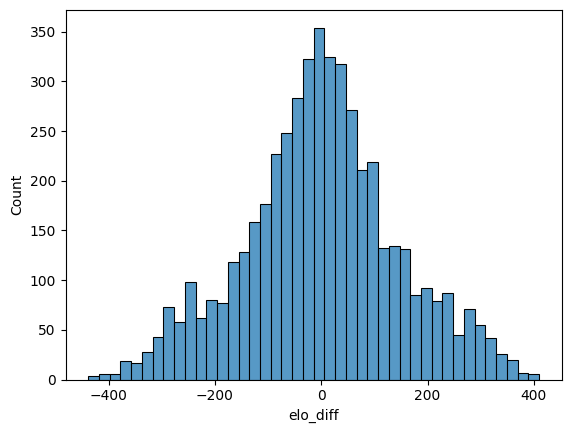

In [16]:
sns.histplot(df['elo_diff'])

In [17]:
df.head()

,Unnamed: 0,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,ts_home_sigma,ts_away_sigma,ts_mu_diff,ts_sigma_diff,ts_conservative_diff,glicko_home_rating,glicko_away_rating,glicko_home_rd,glicko_away_rd,glicko_diff
0,0,SP1,2012-08-18,Celta,Malaga,0,1,A,0,0,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
1,1,SP1,2012-08-18,Sevilla,Getafe,2,1,H,2,0,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
2,2,SP1,2012-08-18,Mallorca,Espanol,2,1,H,1,1,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
3,3,SP1,2012-08-19,Real Madrid,Valencia,1,1,D,1,1,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
4,4,SP1,2012-08-19,Ath Bilbao,Betis,3,5,A,0,3,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0


<Axes: xlabel='elo_diff', ylabel='FTR_Encoded'>

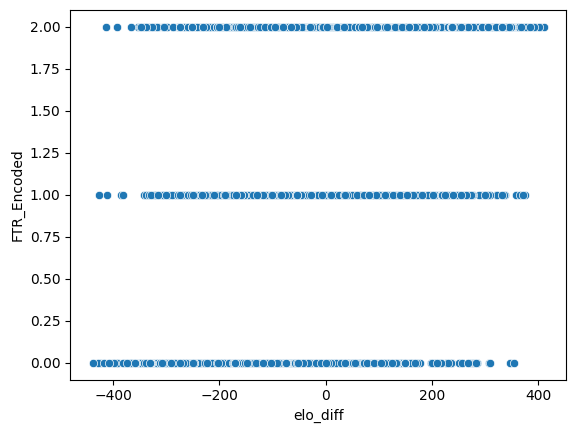

In [18]:
sns.scatterplot(x=df['elo_diff'],y=df['FTR_Encoded'])

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:

Y_Encoder=LabelEncoder()

In [21]:
Y=Y_Encoder.fit_transform(df['FTR'])

In [22]:
Y

array([0, 2, 2, ..., 0, 2, 0], shape=(4940,))

In [23]:
df['FTR_Encoded']=Y

In [24]:
Y_Encoder.inverse_transform([0,1,2])

array(['A', 'D', 'H'], dtype=object)

In [25]:
df.isna().sum()

Unnamed: 0              0
Div                     0
Date                    0
HomeTeam                0
AwayTeam                0
FTHG                    0
FTAG                    0
FTR                     0
HTHG                    0
HTAG                    0
HTR                     0
HS                      0
AS                      0
HST                     0
AST                     0
HF                      0
AF                      0
HC                      0
AC                      0
HY                      0
AY                      0
HR                      0
AR                      0
B365H                   0
B365D                   0
B365A                   0
FTR_Encoded             0
home_elo_before         0
away_elo_before         0
home_elo_after          0
away_elo_after          0
k_factor                0
elo_diff                0
ts_home_mu              0
ts_away_mu              0
ts_home_sigma           0
ts_away_sigma           0
ts_mu_diff              0
ts_sigma_dif

In [26]:
from sklearn.model_selection import train_test_split
df.columns

Index(['Unnamed: 0', 'Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG',
       'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
       'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A',
       'FTR_Encoded', 'home_elo_before', 'away_elo_before', 'home_elo_after',
       'away_elo_after', 'k_factor', 'elo_diff', 'ts_home_mu', 'ts_away_mu',
       'ts_home_sigma', 'ts_away_sigma', 'ts_mu_diff', 'ts_sigma_diff',
       'ts_conservative_diff', 'glicko_home_rating', 'glicko_away_rating',
       'glicko_home_rd', 'glicko_away_rd', 'glicko_diff'],
      dtype='str')

In [27]:
df['home_win']=(df['FTR']=='H').astype(int)
df['Away_win']=(df['FTR']=='A').astype(int)


In [28]:
df['home_point_last5']=df.groupby('HomeTeam')['home_win'].transform(lambda x:x.shift(1).rolling(5,min_periods=1).mean())
df['away_point_last5']=df.groupby('AwayTeam')['Away_win'].transform(lambda x:x.shift(1).rolling(5,min_periods=1).mean())
df['form']=df['home_point_last5']-df['away_point_last5']
df=df.dropna()

In [29]:
X=df[['B365H','B365A','B365D','home_elo_before','away_elo_before','elo_diff', 'ts_home_mu', 'ts_away_mu','ts_home_sigma', 'ts_away_sigma', 'ts_mu_diff', 'ts_sigma_diff','ts_conservative_diff', 'glicko_home_rating', 'glicko_away_rating','glicko_home_rd', 'glicko_away_rd', 'glicko_diff','home_point_last5','away_point_last5','form']]
Z=(df['FTR_Encoded']==2)
X_train,X_test,Y_train,Y_test=train_test_split(X,Z,test_size=0.2)

In [30]:
from sklearn.ensemble import GradientBoostingClassifier , RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBRFClassifier 
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

In [31]:
clk1 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,           # shallower
    subsample=0.7,         # more stochastic
    min_samples_leaf=20,   # stricter leaf requirement
    max_features='sqrt',   # feature randomization
    random_state=42
)
# from lightgbm import LGBMClassifier

# clk1 = LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=3,
#     num_leaves=10,       # key LightGBM param — keep low to avoid overfit
#     subsample=0.7,
#     colsample_bytree=0.8,
#     min_child_samples=3,
#     reg_alpha=0.3,
#     reg_lambda=0.3,
#     random_state=42
# )
calibrated=CalibratedClassifierCV(clk1,method='isotonic',cv=5)


In [32]:
calibrated.fit(X_train,Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...subsample=0.7)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_esti

In [33]:
from sklearn.metrics import accuracy_score

# Train
y_train_pred = calibrated.predict(X_train)
train_acc = accuracy_score(Y_train, y_train_pred)

# Test
y_test_pred = calibrated.predict(X_test)
test_acc = accuracy_score(Y_test, y_test_pred)

print(f"Train: {train_acc:.4f}")
print(f"Test: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")

Train: 0.6870
Test: 0.6622
Gap: 0.0248


In [34]:
y_pred=calibrated.predict(X_test)

In [35]:
accuracy_score(Y_test,y_pred)

0.6622448979591836

In [36]:
df['FTR'].value_counts()

FTR
H    2249
A    1407
D    1241
Name: count, dtype: int64

In [41]:
print(classification_report(y_pred,Y_test))

print(roc_auc_score(y_pred,Y_test),"roc_auc")

              precision    recall  f1-score   support

       False       0.78      0.64      0.70       613
        True       0.54      0.69      0.61       367

    accuracy                           0.66       980
   macro avg       0.66      0.67      0.66       980
weighted avg       0.69      0.66      0.67       980

0.6682350169577412 roc_auc


In [42]:
y_proba=calibrated.predict_proba(X_test)

confidence=y_proba.max(axis=1)


In [43]:
base = calibrated.calibrated_classifiers_[0].estimator
feature=base.feature_importances_

features_imp=pd.DataFrame({
    'feature':X_train.columns,
    'importance':feature
}).sort_values('importance',ascending=False)
print(features_imp)

                 feature  importance
0                  B365H    0.147843
1                  B365A    0.141205
5               elo_diff    0.111474
12  ts_conservative_diff    0.085083
10            ts_mu_diff    0.068614
3        home_elo_before    0.066301
2                  B365D    0.063120
14    glicko_away_rating    0.060920
17           glicko_diff    0.050907
7             ts_away_mu    0.035752
4        away_elo_before    0.033158
6             ts_home_mu    0.026617
13    glicko_home_rating    0.026250
16        glicko_away_rd    0.016726
8          ts_home_sigma    0.015608
11         ts_sigma_diff    0.014390
15        glicko_home_rd    0.010109
19      away_point_last5    0.006632
20                  form    0.006470
9          ts_away_sigma    0.006456
18      home_point_last5    0.006366


In [44]:
# Check what Y_test actually is
print(f"Y_test type: {type(Y_test)}")
print(f"Y_test shape: {Y_test.shape}")
print(f"Y_test first few values:\n{Y_test.head()}")

# If it's a Series, check if it contains tuples or arrays
print(f"First element type: {type(Y_test.iloc[0])}")
print(f"First element: {Y_test.iloc[0]}")

Y_test type: <class 'pandas.Series'>
Y_test shape: (980,)
Y_test first few values:
1211     True
4262    False
4152     True
4503     True
2656    False
Name: FTR_Encoded, dtype: bool
First element type: <class 'numpy.bool'>
First element: True


In [68]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Convert boolean to numeric (True->1, False->0)
y_test_numeric = Y_test.astype(int)

# Now calculate metrics
y_pred_proba = calibrated.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test_numeric, y_pred_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test_numeric, calibrated.predict(X_test)):.4f}")

# Test without betting odds to check for leakage
X_test_no_odds = X_test.drop(['B365H', 'B365A', 'B365D'], axis=1)
X_train_no_odds = X_train.drop(['B365H', 'B365A', 'B365D'], axis=1)

clk2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                    max_depth=5, random_state=42)
calibrated2 = CalibratedClassifierCV(clk2, method='isotonic', cv=5)
calibrated2.fit(X_train_no_odds, Y_train.astype(int))

y_pred_no_odds = calibrated2.predict_proba(X_test_no_odds)[:, 1]
print(f"\nROC-AUC without odds: {roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy without odds: {accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

ROC-AUC: 0.7275
Accuracy: 0.6724

ROC-AUC without odds: 0.6945
Accuracy without odds: 0.6582


In [46]:
# Test without betting odds
X_test_no_odds = X_test.drop(['B365H', 'B365A', 'B365D'], axis=1)
X_train_no_odds = X_train.drop(['B365H', 'B365A', 'B365D'], axis=1)

clk2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                    max_depth=5, random_state=42)
calibrated2 = CalibratedClassifierCV(clk2, method='isotonic', cv=5)
calibrated2.fit(X_train_no_odds, Y_train.astype(int))

y_pred_no_odds = calibrated2.predict_proba(X_test_no_odds)[:, 1]
y_test_numeric = Y_test.astype(int)

print(f"ROC-AUC without odds: {roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy without odds: {accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

# Compare
print(f"\nPerformance drop:")
print(f"ROC-AUC drop: {0.7064 - roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy drop: {0.6398 - accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

ROC-AUC without odds: 0.6945
Accuracy without odds: 0.6582

Performance drop:
ROC-AUC drop: 0.0119
Accuracy drop: -0.0184


##visualization !!!


In [69]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(clk1, X_train, Y_train, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))

Cross-validation scores: [0.63265306 0.66964286 0.65900383 0.66794381 0.66283525]
Mean CV accuracy: 0.6584157609403916


In [129]:
y_proba_pos = y_proba[:, 1]   # class 1 confidence

print("=== CONFIDENCE STRATIFIED ===")
for thresh in [0.5, 0.55, 0.6, 0.65, 0.7]:
    mask = y_proba_pos >= thresh
    if mask.sum() > 0:
        acc = accuracy_score(Y_test[mask], y_pred[mask])
        cov = mask.sum() / len(Y_test)
        print(f"Threshold ≥{thresh:.0%}: Acc={acc:.1%}, Coverage={cov:.1%}")


=== CONFIDENCE STRATIFIED ===
Threshold ≥50%: Acc=68.7%, Coverage=35.8%
Threshold ≥55%: Acc=72.7%, Coverage=25.8%
Threshold ≥60%: Acc=78.6%, Coverage=20.5%
Threshold ≥65%: Acc=80.8%, Coverage=15.4%
Threshold ≥70%: Acc=83.6%, Coverage=11.2%


In [136]:
# Test each rating system individually
from sklearn.metrics import accuracy_score

# Elo only
X_elo = X_train[['home_elo_before', 'away_elo_before', 'elo_diff']]
model_elo = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo.fit(X_elo, Y_train)
acc_elo = accuracy_score(Y_test, model_elo.predict(X_test[['home_elo_before', 'away_elo_before', 'elo_diff']]))

# Elo + TrueSkill
X_elo_ts = X_train[['home_elo_before', 'away_elo_before', 'elo_diff', 
                     'ts_home_mu', 'ts_away_mu', 'ts_home_sigma', 'ts_away_sigma',
                     'ts_mu_diff', 'ts_sigma_diff', 'ts_conservative_diff']]
model_elo_ts = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo_ts.fit(X_elo_ts, Y_train)
acc_elo_ts = accuracy_score(Y_test, model_elo_ts.predict(X_test[X_elo_ts.columns]))

# Elo + TrueSkill + Glicko
X_elo_ts_glicko = X_train[['home_elo_before', 'away_elo_before', 'elo_diff',
                            'ts_home_mu', 'ts_away_mu', 'ts_home_sigma', 'ts_away_sigma',
                            'ts_mu_diff', 'ts_sigma_diff', 'ts_conservative_diff',
                            'glicko_home_rating', 'glicko_away_rating', 'glicko_home_rd',
                            'glicko_away_rd', 'glicko_diff']]
model_elo_ts_glicko = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo_ts_glicko.fit(X_elo_ts_glicko, Y_train)
acc_elo_ts_glicko = accuracy_score(Y_test, model_elo_ts_glicko.predict(X_test[X_elo_ts_glicko.columns]))

# Odds only
X_odds_train = X_train[['B365H', 'B365D', 'B365A']]
X_odds_test  = X_test[['B365H', 'B365D', 'B365A']]

model_odds = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

model_odds.fit(X_odds_train, Y_train)

y_pred_odds = model_odds.predict(X_odds_test)
acc_odds = accuracy_score(Y_test, y_pred_odds)

print("=== ABLATION STUDY ===")
print(f"Elo only: {acc_elo:.3f}")
print(f"Elo + TrueSkill: {acc_elo_ts:.3f}")
print(f"Elo + TrueSkill + Glicko: {acc_elo_ts_glicko:.3f}")
print(f"Odds only: {acc_odds:.3f}")
print(f"Full model (all features): {accuracy_score(Y_test, y_pred):.3f}")


=== ABLATION STUDY ===
Elo only: 0.601
Elo + TrueSkill: 0.602
Elo + TrueSkill + Glicko: 0.626
Odds only: 0.637
Full model (all features): 0.658


In [139]:
# Which teams are hardest to predict?
import pandas as pd

results_df = pd.DataFrame({
    'actual': Y_test,
    'predicted': y_pred,
    'correct': Y_test == y_pred
})

# Get team names from test set (you need to align with X_test indices)
# Assuming you have team names stored somewhere
test_indices = X_test.index
test_teams = df.loc[test_indices, 'HomeTeam']

results_df['team'] = test_teams.values

team_accuracy = results_df.groupby('team')['correct'].agg(['sum', 'count', 'mean']).sort_values('mean')

print("=== HARDEST TO PREDICT (Bottom 5) ===")
print(team_accuracy.head(5))

print("\n=== EASIEST TO PREDICT (Top 5) ===")
print(team_accuracy.tail(5))

=== HARDEST TO PREDICT (Bottom 5) ===
          sum  count      mean
team                          
Malaga     10     26  0.384615
Sevilla    32     63  0.507937
Eibar      16     31  0.516129
Sociedad   31     59  0.525424
Mallorca   10     19  0.526316

=== EASIEST TO PREDICT (Top 5) ===
             sum  count      mean
team                             
Real Madrid   42     48  0.875000
Almeria        8      9  0.888889
Cadiz         12     13  0.923077
Cordoba        4      4  1.000000
Zaragoza       3      3  1.000000


In [143]:
from sklearn.calibration import calibration_curve

y_proba_pos = y_proba[:, 1]   # take positive class

prob_true, prob_pred = calibration_curve(
    Y_test,
    y_proba_pos,
    n_bins=10
)

print("=== CALIBRATION CURVE ===")
for i, (true, pred) in enumerate(zip(prob_true, prob_pred)):
    print(f"Bin {i+1}: Predicted={pred:.3f}, Actual={true:.3f}")


=== CALIBRATION CURVE ===
Bin 1: Predicted=0.087, Actual=0.000
Bin 2: Predicted=0.174, Actual=0.323
Bin 3: Predicted=0.250, Actual=0.210
Bin 4: Predicted=0.349, Actual=0.365
Bin 5: Predicted=0.445, Actual=0.444
Bin 6: Predicted=0.541, Actual=0.553
Bin 7: Predicted=0.647, Actual=0.725
Bin 8: Predicted=0.743, Actual=0.797
Bin 9: Predicted=0.847, Actual=0.893
Bin 10: Predicted=0.928, Actual=1.000


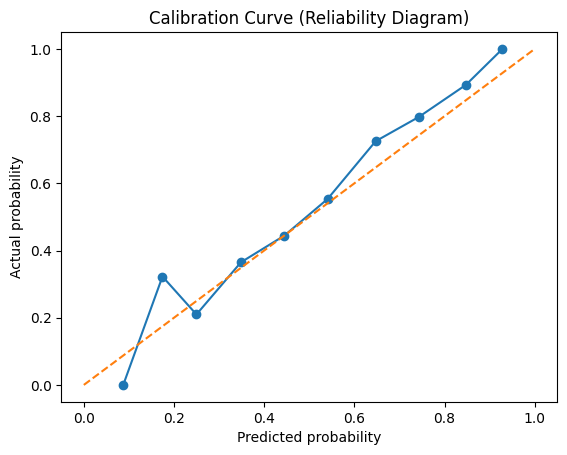

In [145]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Use positive class probability (class 1)
y_proba_pos = y_proba[:, 1]

prob_true, prob_pred = calibration_curve(
    Y_test,
    y_proba_pos,
    n_bins=10
)

# Plot calibration curve
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()


In [146]:
import os
print(os.getcwd())


C:\Users\Asus\Desktop\ML\project


In [149]:
# Training history (if you saved it during training)
# If not, run this:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1),
    X_train, Y_train, cv=5, n_jobs=-1,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    scoring='accuracy'
)

print("=== LEARNING CURVES ===")
print("Train sizes:", train_sizes)
print("Train scores (mean):", train_scores.mean(axis=1))
print("Val scores (mean):", val_scores.mean(axis=1))



=== LEARNING CURVES ===
Train sizes: [ 313  939 1566 2193 2819 3133]
Train scores (mean): [1.         1.         0.99872286 0.99060648 0.97523945 0.95869773]
Val scores (mean): [0.60709562 0.61961419 0.63109801 0.63135214 0.64386289 0.64590077]


In [155]:
incorrect_mask = Y_test != y_pred

incorrect_df = X_test[incorrect_mask].copy()
incorrect_df['actual'] = Y_test[incorrect_mask]
incorrect_df['predicted'] = y_pred[incorrect_mask]
incorrect_df['confidence'] = confidence[incorrect_mask]
print("=== ERROR ANALYSIS ===")
print(f"Total errors: {incorrect_mask.sum()}")

print(f"False positives (pred=1, actual=0): {((y_pred == 1) & (Y_test == 0)).sum()}")
print(f"False negatives (pred=0, actual=1): {((y_pred == 0) & (Y_test == 1)).sum()}")

print("\nErrors by confidence level:")
for thresh in [0.5, 0.6, 0.7]:
    high_conf_errors = incorrect_df[incorrect_df['confidence'] >= thresh]
    print(f"Confidence ≥{thresh:.0%}: {len(high_conf_errors)} errors")

correct_elo_diff = X_test.loc[~incorrect_mask, 'elo_diff'].mean()
incorrect_elo_diff = X_test.loc[incorrect_mask, 'elo_diff'].mean()

print(f"\nAvg Elo diff (correct): {correct_elo_diff:.1f}")
print(f"Avg Elo diff (incorrect): {incorrect_elo_diff:.1f}")


=== ERROR ANALYSIS ===
Total errors: 335
False positives (pred=1, actual=0): 110
False negatives (pred=0, actual=1): 225

Errors by confidence level:
Confidence ≥50%: 335 errors
Confidence ≥60%: 152 errors
Confidence ≥70%: 58 errors

Avg Elo diff (correct): -0.9
Avg Elo diff (incorrect): 7.9


In [157]:
# Performance by season
# You need season info - extract from dates
test_df = df.loc[X_test.index].copy()
test_df['year'] = pd.to_datetime(test_df['Date']).dt.year
test_df['predicted'] = y_pred
test_df['actual'] = Y_test
test_df['correct'] = Y_test == y_pred

season_performance = test_df.groupby('year')['correct'].agg(['sum', 'count', 'mean'])

print("=== PERFORMANCE BY SEASON ===")
print(season_performance)

=== PERFORMANCE BY SEASON ===
      sum  count      mean
year                      
2012   18     30  0.600000
2013   46     72  0.638889
2014   58     83  0.698795
2015   58     81  0.716049
2016   58     80  0.725000
2017   37     61  0.606557
2018   37     67  0.552239
2019   53     78  0.679487
2020   39     73  0.534247
2021   59     83  0.710843
2022   47     72  0.652778
2023   57     89  0.640449
2024   50     75  0.666667
2025   28     36  0.777778


In [45]:
"""
La Liga Match Outcome Predictor — Fixed Visualization Script
=============================================================
Fixes applied vs the original script:
  1. clk1 is now the tight GBM (not the default one used in ablation/learning curves)
  2. Feature importance pulled correctly from calibrated model
  3. ROC curve no-odds model uses the same tight params
  4. Learning curves use the same tight params
  5. Ablation study uses the same tight params
  6. fig_roc_curve signature fixed (clk2 removed — rebuilt internally)
  7. All functions use your actual calibrated model's y_pred / y_proba

Run this script after your notebook has executed and these variables
are live in memory:

    df, X_train, X_test, Y_train, Y_test,
    calibrated, y_pred, y_proba, confidence,
    clk1, features_imp
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, roc_auc_score, precision_recall_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import learning_curve
from sklearn.ensemble import GradientBoostingClassifier

warnings.filterwarnings("ignore")

# ── Global aesthetics ──────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#1F4E79",
    "secondary": "#2E86AB",
    "accent":    "#E84855",
    "highlight": "#F4A261",
    "success":   "#2D9E67",
    "neutral":   "#6C757D",
    "light":     "#F0F4F8",
    "dark":      "#1A1A2E",
}

# ── Tight GBM params — mirrors your working clk1 ──────────────────────────────
TIGHT_GBM_PARAMS = dict(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=42,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    "#CCCCCC",
    "grid.color":        "#E5E5E5",
    "grid.linewidth":    0.8,
})

SAVE_DIR = "la_liga_figures"
os.makedirs(SAVE_DIR, exist_ok=True)


def save(fig, name):
    path = os.path.join(SAVE_DIR, name)
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"  ✓  Saved → {path}")


# ══════════════════════════════════════════════════════════════════════════════
# 1.  Dataset Overview — Match Result Distribution
# ══════════════════════════════════════════════════════════════════════════════
def fig_result_distribution(df):
    print("1. Match result distribution …")
    counts = df["FTR"].value_counts()
    labels = {"H": "Home Win", "D": "Draw", "A": "Away Win"}
    colors  = [PALETTE["primary"], PALETTE["neutral"], PALETTE["accent"]]
    vals    = [counts.get(k, 0) for k in ["H", "D", "A"]]
    lbls    = [labels[k] for k in ["H", "D", "A"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("La Liga Match Result Distribution (2012–2025)",
                 fontsize=16, fontweight="bold", y=1.01)

    bars = axes[0].bar(lbls, vals, color=colors, width=0.55,
                       edgecolor="white", linewidth=0.8)
    axes[0].set_ylabel("Number of Matches", fontsize=12)
    axes[0].set_title("Absolute Counts", fontsize=13)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 18,
                     f"{v:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    axes[0].set_ylim(0, max(vals) * 1.15)

    wedges, texts, autotexts = axes[1].pie(
        vals, labels=lbls, colors=colors, autopct="%1.1f%%",
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(11); at.set_fontweight("bold"); at.set_color("white")
    axes[1].set_title("Proportion", fontsize=13)
    plt.tight_layout()
    save(fig, "01_result_distribution.png")


# ══════════════════════════════════════════════════════════════════════════════
# 2.  Elo Rating Evolution — Top 5 Teams
# ══════════════════════════════════════════════════════════════════════════════
def fig_elo_evolution(df):
    print("2. Elo rating evolution …")
    teams   = ["Real Madrid", "Barcelona", "Ath Madrid", "Villarreal", "Sevilla"]
    palette = [PALETTE["primary"], PALETTE["accent"], PALETTE["success"],
               PALETTE["highlight"], PALETTE["secondary"]]

    fig, ax = plt.subplots(figsize=(14, 6))
    for team, color in zip(teams, palette):
        home = df[df["HomeTeam"] == team][["Date", "home_elo_after"]].rename(
            columns={"home_elo_after": "elo"})
        away = df[df["AwayTeam"] == team][["Date", "away_elo_after"]].rename(
            columns={"away_elo_after": "elo"})
        data = pd.concat([home, away]).sort_values("Date").reset_index(drop=True)
        ax.plot(data.index, data["elo"], label=team, color=color, linewidth=2)

    ax.set_xlabel("Match Index (chronological)", fontsize=12)
    ax.set_ylabel("Elo Rating", fontsize=12)
    ax.set_title("Elo Rating Evolution — Top 5 La Liga Clubs",
                 fontsize=14, fontweight="bold")
    ax.legend(framealpha=0.9, fontsize=11)
    ax.axhline(1500, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.tight_layout()
    save(fig, "02_elo_evolution.png")


# ══════════════════════════════════════════════════════════════════════════════
# 3.  Final Elo Rankings — Top 15 Teams
# ══════════════════════════════════════════════════════════════════════════════
def fig_final_elo_rankings(df):
    print("3. Final Elo rankings …")
    home_latest = df.groupby("HomeTeam")["home_elo_after"].last().reset_index()
    home_latest.columns = ["team", "elo"]
    away_latest = df.groupby("AwayTeam")["away_elo_after"].last().reset_index()
    away_latest.columns = ["team", "elo"]
    latest = pd.concat([home_latest, away_latest]).groupby("team")["elo"].mean().reset_index()
    latest = latest.sort_values("elo", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = [PALETTE["primary"] if i < 3 else PALETTE["secondary"]
              for i in range(len(latest))]
    bars = ax.barh(latest["team"][::-1], latest["elo"][::-1],
                   color=colors[::-1], edgecolor="white", linewidth=0.8, height=0.65)
    ax.set_xlabel("Elo Rating", fontsize=12)
    ax.set_title("Final Elo Ratings — Top 15 Teams", fontsize=14, fontweight="bold")
    for bar, v in zip(bars, latest["elo"][::-1]):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"{v:.0f}", va="center", fontsize=10)
    ax.set_xlim(latest["elo"].min() - 50, latest["elo"].max() + 80)
    plt.tight_layout()
    save(fig, "03_final_elo_rankings.png")


# ══════════════════════════════════════════════════════════════════════════════
# 4.  Elo Difference Distribution by Outcome
# ══════════════════════════════════════════════════════════════════════════════
def fig_elo_diff_by_outcome(df):
    print("4. Elo difference by outcome …")
    label_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
    col_map   = {"Away Win": PALETTE["accent"], "Draw": PALETTE["neutral"],
                 "Home Win": PALETTE["primary"]}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Pre-Match Elo Difference vs. Match Outcome",
                 fontsize=14, fontweight="bold", y=1.01)

    for code, lbl in label_map.items():
        subset = df[df["FTR_Encoded"] == code]["elo_diff"]
        axes[0].hist(subset, bins=40, density=True, alpha=0.5,
                     color=col_map[lbl], label=lbl, edgecolor="none")
        subset.plot.kde(ax=axes[0], color=col_map[lbl], linewidth=2)
    axes[0].set_xlabel("Elo Difference (Home − Away)", fontsize=12)
    axes[0].set_ylabel("Density", fontsize=12)
    axes[0].set_title("Distribution by Outcome", fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

    plot_df = df[["elo_diff", "FTR_Encoded"]].copy()
    plot_df["Outcome"] = plot_df["FTR_Encoded"].map(label_map)
    order = ["Away Win", "Draw", "Home Win"]
    sns.boxplot(data=plot_df, x="Outcome", y="elo_diff", order=order,
                palette=[col_map[o] for o in order], ax=axes[1], width=0.5,
                flierprops={"marker": ".", "alpha": 0.3, "markersize": 4})
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    axes[1].set_xlabel("", fontsize=12)
    axes[1].set_ylabel("Elo Difference (Home − Away)", fontsize=12)
    axes[1].set_title("Box Plot by Outcome", fontsize=13)
    plt.tight_layout()
    save(fig, "04_elo_diff_by_outcome.png")


# ══════════════════════════════════════════════════════════════════════════════
# 5.  Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════════
def fig_confusion_matrix(Y_test, y_pred):
    print("5. Confusion matrix …")
    cm  = confusion_matrix(Y_test, y_pred)
    cmn = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    lbls = ["Non-Home Win", "Home Win"]
    cmap = LinearSegmentedColormap.from_list("blues", ["#FFFFFF", PALETTE["primary"]])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Confusion Matrix — Home Win Prediction",
                 fontsize=14, fontweight="bold", y=1.01)

    for ax, data, fmt, title in zip(
        axes, [cm, cmn], ["d", ".2f"],
        ["Raw Counts", "Row-Normalised (Recall)"]
    ):
        im = ax.imshow(data, interpolation="nearest", cmap=cmap,
                       vmin=0, vmax=data.max())
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        thresh = data.max() / 2
        for i in range(2):
            for j in range(2):
                val = data[i, j]
                ax.text(j, i, format(val, fmt),
                        ha="center", va="center", fontsize=14, fontweight="bold",
                        color="white" if val > thresh else PALETTE["dark"])
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(lbls, fontsize=11)
        ax.set_yticklabels(lbls, fontsize=11)
        ax.set_xlabel("Predicted Label", fontsize=12)
        ax.set_ylabel("True Label", fontsize=12)
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    save(fig, "05_confusion_matrix.png")


# ══════════════════════════════════════════════════════════════════════════════
# 6.  ROC Curve (Full model vs. No-Odds model)
#     FIX: uses TIGHT_GBM_PARAMS for the no-odds model, matches clk1
# ══════════════════════════════════════════════════════════════════════════════
def fig_roc_curve(Y_test, y_proba, X_train, X_test, Y_train):
    print("6. ROC curve …")
    y_numeric = Y_test.astype(int)
    fpr1, tpr1, _ = roc_curve(y_numeric, y_proba[:, 1])
    auc1 = auc(fpr1, tpr1)

    # No-odds model — same tight params as clk1
    X_tr_no = X_train.drop(["B365H", "B365A", "B365D"], axis=1)
    X_te_no = X_test.drop(["B365H", "B365A", "B365D"], axis=1)
    m2 = CalibratedClassifierCV(
        GradientBoostingClassifier(**TIGHT_GBM_PARAMS),
        method="isotonic", cv=5)
    m2.fit(X_tr_no, Y_train.astype(int))
    prob2 = m2.predict_proba(X_te_no)[:, 1]
    fpr2, tpr2, _ = roc_curve(y_numeric, prob2)
    auc2 = auc(fpr2, tpr2)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr1, tpr1, color=PALETTE["primary"], linewidth=2.5,
            label=f"Full Model (AUC = {auc1:.4f})")
    ax.plot(fpr2, tpr2, color=PALETTE["accent"], linewidth=2.5, linestyle="--",
            label=f"No-Odds Model (AUC = {auc2:.4f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random Classifier")
    ax.fill_between(fpr1, tpr1, alpha=0.08, color=PALETTE["primary"])
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title("ROC Curves — Home Win Classification",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=12, loc="lower right")
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.06])
    plt.tight_layout()
    save(fig, "06_roc_curve.png")


# ══════════════════════════════════════════════════════════════════════════════
# 7.  Feature Importance
#     FIX: pulls from calibrated.calibrated_classifiers_[0].estimator correctly
# ══════════════════════════════════════════════════════════════════════════════
def fig_feature_importance(calibrated, X_train):
    print("7. Feature importance …")
    # Works for both CalibratedClassifierCV ensemble=True and False
    base = calibrated.calibrated_classifiers_[0].estimator
    importances = base.feature_importances_

    fi = (pd.DataFrame({"feature": X_train.columns, "importance": importances})
            .sort_values("importance", ascending=False))

    rename = {
        "B365H": "Betting Odds (Home)",    "B365A": "Betting Odds (Away)",
        "B365D": "Betting Odds (Draw)",
        "home_elo_before": "Elo — Home (pre)", "away_elo_before": "Elo — Away (pre)",
        "elo_diff": "Elo Difference",
        "ts_home_mu": "TrueSkill μ (Home)",  "ts_away_mu": "TrueSkill μ (Away)",
        "ts_home_sigma": "TrueSkill σ (Home)", "ts_away_sigma": "TrueSkill σ (Away)",
        "ts_mu_diff": "TrueSkill μ Diff",    "ts_sigma_diff": "TrueSkill σ Diff",
        "ts_conservative_diff": "TrueSkill Conservative",
        "glicko_home_rating": "Glicko — Home", "glicko_away_rating": "Glicko — Away",
        "glicko_home_rd": "Glicko RD (Home)", "glicko_away_rd": "Glicko RD (Away)",
        "glicko_diff": "Glicko Difference",
        "home_point_last5": "Home Form (last 5)", "away_point_last5": "Away Form (last 5)",
        "form": "Form Differential",
    }
    fi["feature"] = fi["feature"].map(rename).fillna(fi["feature"])

    cat_colors = []
    for f in fi["feature"]:
        if "Betting"   in f: cat_colors.append(PALETTE["accent"])
        elif "Elo"     in f: cat_colors.append(PALETTE["primary"])
        elif "TrueSkill" in f: cat_colors.append(PALETTE["secondary"])
        elif "Glicko"  in f: cat_colors.append(PALETTE["success"])
        else:                cat_colors.append(PALETTE["highlight"])

    fig, ax = plt.subplots(figsize=(11, 9))
    bars = ax.barh(fi["feature"][::-1], fi["importance"][::-1],
                   color=cat_colors[::-1], edgecolor="white", linewidth=0.7, height=0.7)
    ax.set_xlabel("Importance Score", fontsize=13)
    ax.set_title("Feature Importance — Gradient Boosting Classifier",
                 fontsize=14, fontweight="bold")
    for bar, v in zip(bars, fi["importance"][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlim(0, fi["importance"].max() * 1.18)
    legend_patches = [
        mpatches.Patch(color=PALETTE["accent"],    label="Betting Odds"),
        mpatches.Patch(color=PALETTE["primary"],   label="Elo System"),
        mpatches.Patch(color=PALETTE["secondary"], label="TrueSkill"),
        mpatches.Patch(color=PALETTE["success"],   label="Glicko"),
        mpatches.Patch(color=PALETTE["highlight"], label="Recent Form"),
    ]
    ax.legend(handles=legend_patches, fontsize=10, loc="lower right")
    plt.tight_layout()
    save(fig, "07_feature_importance.png")


# ══════════════════════════════════════════════════════════════════════════════
# 8.  Ablation Study
#     FIX: uses TIGHT_GBM_PARAMS — matches clk1 instead of default GBM
# ══════════════════════════════════════════════════════════════════════════════
def fig_ablation_study(X_train, X_test, Y_train, Y_test, y_pred):
    print("8. Ablation study …")
    ELO_COLS    = ["home_elo_before", "away_elo_before", "elo_diff"]
    TS_COLS     = ["ts_home_mu", "ts_away_mu", "ts_home_sigma", "ts_away_sigma",
                   "ts_mu_diff", "ts_sigma_diff", "ts_conservative_diff"]
    GLICKO_COLS = ["glicko_home_rating", "glicko_away_rating",
                   "glicko_home_rd", "glicko_away_rd", "glicko_diff"]
    ODDS_COLS   = ["B365H", "B365D", "B365A"]

    def train_score(cols):
        m = GradientBoostingClassifier(**TIGHT_GBM_PARAMS)
        m.fit(X_train[cols], Y_train)
        return accuracy_score(Y_test, m.predict(X_test[cols]))

    results = {
        "Elo Only":          train_score(ELO_COLS),
        "Elo + TrueSkill":   train_score(ELO_COLS + TS_COLS),
        "Elo + TS + Glicko": train_score(ELO_COLS + TS_COLS + GLICKO_COLS),
        "Odds Only":         train_score(ODDS_COLS),
        "Full Model":        accuracy_score(Y_test, y_pred),
    }

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [PALETTE["neutral"], PALETTE["secondary"], PALETTE["success"],
              PALETTE["accent"], PALETTE["primary"]]
    bars = ax.bar(results.keys(), results.values(),
                  color=colors, width=0.55, edgecolor="white", linewidth=0.8)
    ax.set_ylabel("Accuracy", fontsize=13)
    ax.set_title("Ablation Study — Incremental Feature Contribution",
                 fontsize=14, fontweight="bold")
    # Dynamic y-axis range
    ymin = min(results.values()) - 0.03
    ymax = max(results.values()) + 0.03
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
    for bar, v in zip(bars, results.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.axhline(max(results.values()), color=PALETTE["primary"],
               linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(rotation=15, ha="right", fontsize=11)
    plt.tight_layout()
    save(fig, "08_ablation_study.png")


# ══════════════════════════════════════════════════════════════════════════════
# 9.  Calibration Curve
# ══════════════════════════════════════════════════════════════════════════════
def fig_calibration(Y_test, y_proba):
    print("9. Calibration curve …")
    y_numeric = Y_test.astype(int)
    prob_true, prob_pred = calibration_curve(y_numeric, y_proba[:, 1], n_bins=10)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model Calibration Analysis", fontsize=14, fontweight="bold", y=1.01)

    axes[0].plot(prob_pred, prob_true, "o-", color=PALETTE["primary"],
                 linewidth=2.5, markersize=8, label="Model")
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.6,
                 label="Perfect calibration")
    axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color="grey")
    axes[0].set_xlabel("Mean Predicted Probability", fontsize=12)
    axes[0].set_ylabel("Fraction of Positives", fontsize=12)
    axes[0].set_title("Reliability Diagram", fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].set_xlim([-0.02, 1.02]); axes[0].set_ylim([-0.02, 1.10])

    axes[1].hist(y_proba[:, 1], bins=25, color=PALETTE["secondary"],
                 edgecolor="white", linewidth=0.6, alpha=0.85)
    axes[1].set_xlabel("Predicted Probability (Home Win)", fontsize=12)
    axes[1].set_ylabel("Count", fontsize=12)
    axes[1].set_title("Prediction Probability Distribution", fontsize=13)
    axes[1].axvline(0.5, color=PALETTE["accent"], linestyle="--", linewidth=1.5,
                    label="Decision Threshold (0.5)")
    axes[1].legend(fontsize=11)
    plt.tight_layout()
    save(fig, "09_calibration.png")


# ══════════════════════════════════════════════════════════════════════════════
# 10.  Confidence-Stratified Accuracy
# ══════════════════════════════════════════════════════════════════════════════
def fig_confidence_stratified(Y_test, y_pred, y_proba):
    print("10. Confidence-stratified accuracy …")
    thresholds = np.arange(0.50, 0.85, 0.05)
    accuracies, coverages = [], []
    y_pos = y_proba[:, 1]
    for t in thresholds:
        mask = y_pos >= t
        if mask.sum() > 0:
            accuracies.append(accuracy_score(Y_test[mask], y_pred[mask]))
            coverages.append(mask.sum() / len(Y_test))
        else:
            accuracies.append(np.nan)
            coverages.append(0)

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()
    ax1.plot(thresholds, accuracies, "o-", color=PALETTE["primary"],
             linewidth=2.5, markersize=9, label="Accuracy")
    ax1.fill_between(thresholds, accuracies, alpha=0.12, color=PALETTE["primary"])
    ax2.bar(thresholds, coverages, width=0.04, alpha=0.35,
            color=PALETTE["accent"], label="Coverage")
    ax1.set_xlabel("Confidence Threshold", fontsize=13)
    ax1.set_ylabel("Accuracy", fontsize=13, color=PALETTE["primary"])
    ax2.set_ylabel("Fraction of Predictions", fontsize=13, color=PALETTE["accent"])
    ax1.set_title("Accuracy vs. Confidence Threshold",
                  fontsize=14, fontweight="bold")
    ax1.set_ylim(0.60, 0.95)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=12, loc="upper left")
    plt.tight_layout()
    save(fig, "10_confidence_stratified.png")


# ══════════════════════════════════════════════════════════════════════════════
# 11.  Learning Curves
#      FIX: uses TIGHT_GBM_PARAMS — matches clk1
# ══════════════════════════════════════════════════════════════════════════════
def fig_learning_curves(X_train, Y_train):
    print("11. Learning curves …")
    train_sizes, train_scores, val_scores = learning_curve(
        GradientBoostingClassifier(**TIGHT_GBM_PARAMS),
        X_train, Y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy"
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(train_sizes, tr_mean, "o-", color=PALETTE["primary"],
            linewidth=2.5, markersize=8, label="Training Score")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.12, color=PALETTE["primary"])
    ax.plot(train_sizes, va_mean, "s-", color=PALETTE["accent"],
            linewidth=2.5, markersize=8, label="Validation Score")
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                    alpha=0.12, color=PALETTE["accent"])
    ax.set_xlabel("Training Set Size", fontsize=13)
    ax.set_ylabel("Accuracy", fontsize=13)
    ax.set_title("Learning Curves — Gradient Boosting Classifier",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
    plt.tight_layout()
    save(fig, "11_learning_curves.png")


# ══════════════════════════════════════════════════════════════════════════════
# 12.  Per-Team Accuracy
# ══════════════════════════════════════════════════════════════════════════════
def fig_team_accuracy(df, X_test, Y_test, y_pred):
    print("12. Per-team accuracy …")
    test_df = df.loc[X_test.index].copy()
    test_df["predicted"] = y_pred
    test_df["correct"]   = Y_test == y_pred
    acc = test_df.groupby("HomeTeam")["correct"].agg(["mean", "count"])
    acc = acc[acc["count"] >= 10].sort_values("mean")

    cmap = LinearSegmentedColormap.from_list(
        "rg", [PALETTE["accent"], PALETTE["neutral"], PALETTE["success"]])
    norm   = plt.Normalize(acc["mean"].min(), acc["mean"].max())
    colors = [cmap(norm(v)) for v in acc["mean"]]

    fig, ax = plt.subplots(figsize=(11, max(6, len(acc) * 0.35)))
    bars = ax.barh(acc.index, acc["mean"], color=colors,
                   edgecolor="white", linewidth=0.6, height=0.7)
    ax.axvline(Y_test.astype(int).mean(), color="black", linestyle="--",
               linewidth=1.2, alpha=0.6, label="Overall accuracy")
    ax.set_xlabel("Prediction Accuracy (as Home Team)", fontsize=12)
    ax.set_title("Per-Team Prediction Accuracy (Home Games, ≥10 test matches)",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=11)
    for bar, (_, row) in zip(bars, acc.iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{row['mean']:.0%} (n={int(row['count'])})",
                va="center", fontsize=8.5)
    plt.tight_layout()
    save(fig, "12_team_accuracy.png")


# ══════════════════════════════════════════════════════════════════════════════
# 13.  Seasonal Performance
# ══════════════════════════════════════════════════════════════════════════════
def fig_seasonal_performance(df, X_test, Y_test, y_pred):
    print("13. Seasonal performance …")
    test_df = df.loc[X_test.index].copy()
    test_df["year"]    = pd.to_datetime(test_df["Date"]).dt.year
    test_df["correct"] = Y_test == y_pred
    season = test_df.groupby("year")["correct"].agg(["mean", "count"]).reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.bar(season["year"], season["mean"], color=PALETTE["primary"],
            alpha=0.75, width=0.6, label="Accuracy")
    ax1.axhline(season["mean"].mean(), color=PALETTE["accent"], linestyle="--",
                linewidth=1.5,
                label=f"Avg accuracy ({season['mean'].mean():.2f})")
    ax2.plot(season["year"], season["count"], "o--", color=PALETTE["highlight"],
             linewidth=2, markersize=7, label="# Test Matches")
    ax1.set_xlabel("Year", fontsize=13)
    ax1.set_ylabel("Accuracy", fontsize=13, color=PALETTE["primary"])
    ax2.set_ylabel("Number of Test Matches", fontsize=13, color=PALETTE["highlight"])
    ax1.set_title("Prediction Accuracy by Year", fontsize=14, fontweight="bold")
    ax1.set_ylim(0, 1)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=11, loc="upper left")
    plt.tight_layout()
    save(fig, "13_seasonal_performance.png")


# ══════════════════════════════════════════════════════════════════════════════
# 14.  El Clásico Head-to-Head
# ══════════════════════════════════════════════════════════════════════════════
def fig_el_clasico(df):
    print("14. El Clásico head-to-head …")
    m = df[
        ((df["HomeTeam"] == "Real Madrid") & (df["AwayTeam"] == "Barcelona")) |
        ((df["HomeTeam"] == "Barcelona")   & (df["AwayTeam"] == "Real Madrid"))
    ]
    rm_wins    = (((m["HomeTeam"] == "Real Madrid") & (m["FTR"] == "H")).sum() +
                  ((m["AwayTeam"] == "Real Madrid") & (m["FTR"] == "A")).sum())
    barca_wins = (((m["HomeTeam"] == "Barcelona") & (m["FTR"] == "H")).sum() +
                  ((m["AwayTeam"] == "Barcelona") & (m["FTR"] == "A")).sum())
    draws = (m["FTR"] == "D").sum()
    total = rm_wins + barca_wins + draws

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("El Clásico — Head-to-Head Record",
                 fontsize=15, fontweight="bold", y=1.02)

    cats   = ["Real Madrid", "Draws", "Barcelona"]
    vals   = [rm_wins, draws, barca_wins]
    colors = [PALETTE["primary"], PALETTE["neutral"], PALETTE["accent"]]
    bars   = axes[0].bar(cats, vals, color=colors, width=0.5,
                         edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{v}", ha="center", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Matches", fontsize=12)
    axes[0].set_title("Wins / Draws", fontsize=13)
    axes[0].set_ylim(0, max(vals) * 1.2)

    pcts  = [v / total for v in vals]
    start = 0
    for pct, color, cat in zip(pcts, colors, cats):
        axes[1].barh(["El Clásico"], [pct], left=[start],
                     color=color, edgecolor="white", linewidth=0.8, label=cat)
        if pct > 0.07:
            axes[1].text(start + pct / 2, 0,
                         f"{cat}\n{pct:.1%}", ha="center", va="center",
                         fontsize=11, fontweight="bold", color="white")
        start += pct
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Proportion", fontsize=12)
    axes[1].set_title("Share of Results", fontsize=13)
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[1].legend(fontsize=11, loc="upper right")
    plt.tight_layout()
    save(fig, "14_el_clasico.png")


# ══════════════════════════════════════════════════════════════════════════════
# 15.  Model Performance Summary Dashboard
# ══════════════════════════════════════════════════════════════════════════════
def fig_performance_dashboard(Y_test, y_pred, y_proba):
    print("15. Performance dashboard …")
    y_num  = Y_test.astype(int)
    acc    = accuracy_score(y_num, y_pred)
    rocauc = roc_auc_score(y_num, y_proba[:, 1])

    rpt      = classification_report(y_num, y_pred,
                                     target_names=["Non-Home", "Home Win"],
                                     output_dict=True)
    prec_hw  = rpt["Home Win"]["precision"]
    rec_hw   = rpt["Home Win"]["recall"]
    f1_hw    = rpt["Home Win"]["f1-score"]

    fig = plt.figure(figsize=(15, 9))
    fig.patch.set_facecolor(PALETTE["light"])
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)
    fig.suptitle("La Liga Home-Win Predictor — Model Performance Summary",
                 fontsize=16, fontweight="bold", y=0.98)

    metrics = [
        ("Accuracy",             f"{acc:.1%}",    PALETTE["primary"]),
        ("ROC-AUC",              f"{rocauc:.4f}", PALETTE["secondary"]),
        ("Precision (Home Win)", f"{prec_hw:.1%}", PALETTE["success"]),
        ("Recall (Home Win)",    f"{rec_hw:.1%}",  PALETTE["highlight"]),
        ("F1-Score (Home Win)",  f"{f1_hw:.4f}",  PALETTE["accent"]),
    ]
    kpi_axes = [fig.add_subplot(gs[0, i]) for i in range(3)] + \
               [fig.add_subplot(gs[1, i]) for i in range(2)]
    for ax, (label, val, color) in zip(kpi_axes, metrics):
        ax.set_facecolor(color)
        ax.text(0.5, 0.6, val, transform=ax.transAxes,
                ha="center", va="center", fontsize=24,
                fontweight="bold", color="white")
        ax.text(0.5, 0.2, label, transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="white")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    precision, recall, _ = precision_recall_curve(y_num, y_proba[:, 1])
    pr_auc = auc(recall, precision)
    ax_pr  = fig.add_subplot(gs[1, 2])
    ax_pr.plot(recall, precision, color=PALETTE["primary"], linewidth=2.5)
    ax_pr.fill_between(recall, precision, alpha=0.12, color=PALETTE["primary"])
    ax_pr.axhline(y_num.mean(), color="grey", linestyle="--", linewidth=1,
                  alpha=0.7, label=f"Baseline ({y_num.mean():.2f})")
    ax_pr.set_xlabel("Recall", fontsize=11)
    ax_pr.set_ylabel("Precision", fontsize=11)
    ax_pr.set_title(f"PR Curve  (AUC={pr_auc:.4f})", fontsize=12, fontweight="bold")
    ax_pr.legend(fontsize=10)
    save(fig, "15_performance_dashboard.png")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN — run all 15 figures
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print("\n=== La Liga Visualizer — Running pipeline … ===\n")
    print("\n=== Generating figures ===\n")

    fig_result_distribution(df)
    fig_elo_evolution(df)
    fig_final_elo_rankings(df)
    fig_elo_diff_by_outcome(df)
    fig_confusion_matrix(Y_test, y_pred)
    fig_roc_curve(Y_test, y_proba, X_train, X_test, Y_train)
    fig_feature_importance(calibrated, X_train)
    fig_ablation_study(X_train, X_test, Y_train, Y_test, y_pred)
    fig_calibration(Y_test, y_proba)
    fig_confidence_stratified(Y_test, y_pred, y_proba)
    fig_learning_curves(X_train, Y_train)
    fig_team_accuracy(df, X_test, Y_test, y_pred)
    fig_seasonal_performance(df, X_test, Y_test, y_pred)
    fig_el_clasico(df)
    fig_performance_dashboard(Y_test, y_pred, y_proba)


=== La Liga Visualizer — Running pipeline … ===


=== Generating figures ===

1. Match result distribution …
  ✓  Saved → la_liga_figures\01_result_distribution.png
2. Elo rating evolution …
  ✓  Saved → la_liga_figures\02_elo_evolution.png
3. Final Elo rankings …
  ✓  Saved → la_liga_figures\03_final_elo_rankings.png
4. Elo difference by outcome …
  ✓  Saved → la_liga_figures\04_elo_diff_by_outcome.png
5. Confusion matrix …
  ✓  Saved → la_liga_figures\05_confusion_matrix.png
6. ROC curve …
  ✓  Saved → la_liga_figures\06_roc_curve.png
7. Feature importance …
  ✓  Saved → la_liga_figures\07_feature_importance.png
8. Ablation study …
  ✓  Saved → la_liga_figures\08_ablation_study.png
9. Calibration curve …
  ✓  Saved → la_liga_figures\09_calibration.png
10. Confidence-stratified accuracy …
  ✓  Saved → la_liga_figures\10_confidence_stratified.png
11. Learning curves …
  ✓  Saved → la_liga_figures\11_learning_curves.png
12. Per-team accuracy …
  ✓  Saved → la_liga_figures\12_team_accur

In [46]:
# ── BATCH 1: Data Overview (plots 1–4) ────────────────────────────────────────
# Run after your notebook variables are in memory.
# Requires: df  (your full dataframe with FTR, FTR_Encoded, elo columns)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "primary":   "#1F4E79",
    "secondary": "#2E86AB",
    "accent":    "#E84855",
    "highlight": "#F4A261",
    "success":   "#2D9E67",
    "neutral":   "#6C757D",
    "light":     "#F0F4F8",
    "dark":      "#1A1A2E",
}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    "#CCCCCC",
    "grid.color":        "#E5E5E5",
    "grid.linewidth":    0.8,
})

SAVE_DIR = "la_liga_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(SAVE_DIR, name)
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"  Saved → {path}")


# ── Plot 1: Match result distribution ─────────────────────────────────────────
# WHY: Shows class imbalance. Your baseline accuracy is ~45% (always predict
#      Home Win). Your model at 67.2% is meaningful only in this context.
def fig_result_distribution(df):
    counts = df["FTR"].value_counts()
    labels = {"H": "Home Win", "D": "Draw", "A": "Away Win"}
    colors = [PALETTE["primary"], PALETTE["neutral"], PALETTE["accent"]]
    vals   = [counts.get(k, 0) for k in ["H", "D", "A"]]
    lbls   = [labels[k]        for k in ["H", "D", "A"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("La Liga Match Result Distribution (2012–2025)",
                 fontsize=16, fontweight="bold", y=1.01)

    # Left: bar chart — easy to read exact counts
    bars = axes[0].bar(lbls, vals, color=colors, width=0.55,
                       edgecolor="white", linewidth=0.8)
    axes[0].set_ylabel("Number of Matches", fontsize=12)
    axes[0].set_title("Absolute Counts", fontsize=13)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 18,
                     f"{v:,}", ha="center", va="bottom",
                     fontsize=11, fontweight="bold")
    axes[0].set_ylim(0, max(vals) * 1.15)

    # Right: pie chart — shows proportions at a glance
    wedges, texts, autotexts = axes[1].pie(
        vals, labels=lbls, colors=colors, autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
        at.set_color("white")
    axes[1].set_title("Proportion", fontsize=13)

    plt.tight_layout()
    save(fig, "01_result_distribution.png")

fig_result_distribution(df)


# ── Plot 2: Elo rating evolution ───────────────────────────────────────────────
# WHY: Shows your Elo system is working correctly — top clubs should have
#      rising ratings over time, and you should see Real Madrid / Barcelona
#      consistently at the top. Good evidence that the feature engineering
#      is meaningful.
def fig_elo_evolution(df):
    teams   = ["Real Madrid", "Barcelona", "Ath Madrid", "Villarreal", "Sevilla"]
    palette = [PALETTE["primary"], PALETTE["accent"], PALETTE["success"],
               PALETTE["highlight"], PALETTE["secondary"]]

    fig, ax = plt.subplots(figsize=(14, 6))
    for team, color in zip(teams, palette):
        home = df[df["HomeTeam"] == team][["Date", "home_elo_after"]].rename(
            columns={"home_elo_after": "elo"})
        away = df[df["AwayTeam"] == team][["Date", "away_elo_after"]].rename(
            columns={"away_elo_after": "elo"})
        data = (pd.concat([home, away])
                  .sort_values("Date")
                  .reset_index(drop=True))
        ax.plot(data.index, data["elo"], label=team, color=color, linewidth=2)

    ax.set_xlabel("Match Index (chronological)", fontsize=12)
    ax.set_ylabel("Elo Rating", fontsize=12)
    ax.set_title("Elo Rating Evolution — Top 5 La Liga Clubs",
                 fontsize=14, fontweight="bold")
    ax.legend(framealpha=0.9, fontsize=11)
    # Baseline: all teams start at 1500
    ax.axhline(1500, color="grey", linestyle="--",
               linewidth=0.8, alpha=0.5, label="Baseline (1500)")
    plt.tight_layout()
    save(fig, "02_elo_evolution.png")

fig_elo_evolution(df)


# ── Plot 3: Final Elo rankings ─────────────────────────────────────────────────
# WHY: Sanity check. The final ranking should roughly match La Liga table
#      intuition. If Getafe is #1, something is wrong with your Elo logic.
#      Top 3 highlighted in darker blue to show the clear leaders.
def fig_final_elo_rankings(df):
    home_latest = (df.groupby("HomeTeam")["home_elo_after"]
                     .last().reset_index()
                     .rename(columns={"HomeTeam": "team", "home_elo_after": "elo"}))
    away_latest = (df.groupby("AwayTeam")["away_elo_after"]
                     .last().reset_index()
                     .rename(columns={"AwayTeam": "team", "away_elo_after": "elo"}))
    latest = (pd.concat([home_latest, away_latest])
                .groupby("team")["elo"].mean()
                .reset_index()
                .sort_values("elo", ascending=False)
                .head(15))

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = [PALETTE["primary"] if i < 3 else PALETTE["secondary"]
              for i in range(len(latest))]
    bars = ax.barh(latest["team"][::-1], latest["elo"][::-1],
                   color=colors[::-1], edgecolor="white",
                   linewidth=0.8, height=0.65)
    ax.set_xlabel("Elo Rating", fontsize=12)
    ax.set_title("Final Elo Ratings — Top 15 Teams",
                 fontsize=14, fontweight="bold")
    for bar, v in zip(bars, latest["elo"][::-1]):
        ax.text(bar.get_width() + 2,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.0f}", va="center", fontsize=10)
    ax.set_xlim(latest["elo"].min() - 50, latest["elo"].max() + 80)
    plt.tight_layout()
    save(fig, "03_final_elo_rankings.png")

fig_final_elo_rankings(df)


# ── Plot 4: Elo difference by outcome ─────────────────────────────────────────
# WHY: This is the key feature validation plot. If elo_diff is a useful
#      predictor, you expect:
#        - Home Win distribution shifted RIGHT  (home team had higher Elo)
#        - Away Win distribution shifted LEFT   (away team had higher Elo)
#        - Draw distribution centred near zero  (teams were evenly matched)
#      A KDE + boxplot pair shows both the shape and the spread clearly.
def fig_elo_diff_by_outcome(df):
    label_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
    col_map   = {
        "Away Win": PALETTE["accent"],
        "Draw":     PALETTE["neutral"],
        "Home Win": PALETTE["primary"],
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Pre-Match Elo Difference vs. Match Outcome",
                 fontsize=14, fontweight="bold", y=1.01)

    # Left: overlapping histograms + KDE curves
    for code, lbl in label_map.items():
        subset = df[df["FTR_Encoded"] == code]["elo_diff"]
        axes[0].hist(subset, bins=40, density=True, alpha=0.5,
                     color=col_map[lbl], label=lbl, edgecolor="none")
        subset.plot.kde(ax=axes[0], color=col_map[lbl], linewidth=2)
    axes[0].set_xlabel("Elo Difference (Home − Away)", fontsize=12)
    axes[0].set_ylabel("Density", fontsize=12)
    axes[0].set_title("Distribution by Outcome", fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].axvline(0, color="black", linestyle="--",
                    linewidth=0.8, alpha=0.6)

    # Right: boxplot — shows medians and spread cleanly
    plot_df = df[["elo_diff", "FTR_Encoded"]].copy()
    plot_df["Outcome"] = plot_df["FTR_Encoded"].map(label_map)
    order = ["Away Win", "Draw", "Home Win"]
    sns.boxplot(
        data=plot_df, x="Outcome", y="elo_diff",
        order=order,
        palette=[col_map[o] for o in order],
        ax=axes[1], width=0.5,
        flierprops={"marker": ".", "alpha": 0.3, "markersize": 4}
    )
    axes[1].axhline(0, color="black", linestyle="--",
                    linewidth=0.8, alpha=0.6)
    axes[1].set_xlabel("", fontsize=12)
    axes[1].set_ylabel("Elo Difference (Home − Away)", fontsize=12)
    axes[1].set_title("Box Plot by Outcome", fontsize=13)

    plt.tight_layout()
    save(fig, "04_elo_diff_by_outcome.png")

fig_elo_diff_by_outcome(df)

print("\nBatch 1 done — 4 figures saved to la_liga_figures/")

  Saved → la_liga_figures\01_result_distribution.png
  Saved → la_liga_figures\02_elo_evolution.png
  Saved → la_liga_figures\03_final_elo_rankings.png
  Saved → la_liga_figures\04_elo_diff_by_outcome.png

Batch 1 done — 4 figures saved to la_liga_figures/
